In [ ]:
from google.colab import files
files.upload()   # upload kaggle.json

Saving kaggle (1).json to kaggle (1) (1).json


{'kaggle (1) (1).json': b'{"username":"shubham014","key":"91c5980a226e1306b32318b26faebdb5"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp "kaggle (1).json" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!cp "kaggle (1).json" ~/.kaggle/

In [ ]:
!kaggle datasets download -d salmansajid05/oral-diseases
!unzip oral-diseases.zip -d /content/oral_diseases

Streaming output truncated to the last 5000 lines.
  inflating: /content/oral_diseases/Mouth Ulcer/Mouth Ulcer/Mouth_Ulcer_augmented_DataSet/preview/Mouth_Ulcer_0_4772.jpeg  
  inflating: /content/oral_diseases/Mouth Ulcer/Mouth Ulcer/Mouth_Ulcer_augmented_DataSet/preview/Mouth_Ulcer_0_4773.jpeg  
  inflating: /content/oral_diseases/Mouth Ulcer/Mouth Ulcer/Mouth_Ulcer_augmented_DataSet/preview/Mouth_Ulcer_0_4776.jpeg  
  inflating: /content/oral_diseases/Mouth Ulcer/Mouth Ulcer/Mouth_Ulcer_augmented_DataSet/preview/Mouth_Ulcer_0_4782.jpeg  
  inflating: /content/oral_diseases/Mouth Ulcer/Mouth Ulcer/Mouth_Ulcer_augmented_DataSet/preview/Mouth_Ulcer_0_4803.jpeg  
  inflating: /content/oral_diseases/Mouth Ulcer/Mouth Ulcer/Mouth_Ulcer_augmented_DataSet/preview/Mouth_Ulcer_0_4807.jpeg  
  inflating: /content/oral_diseases/Mouth Ulcer/Mouth Ulcer/Mouth_Ulcer_augmented_DataSet/preview/Mouth_Ulcer_0_4808.jpeg  
  inflating: /content/oral_diseases/Mouth Ulcer/Mouth Ulcer/Mouth_Ulcer_augmented

In [ ]:
!ls /content/oral_diseases


 Calculus
 Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset
'Data caries'
 Gingivitis
 hypodontia
'Mouth Ulcer'
'Tooth Discoloration'


In [ ]:
# ===============================
# SECTION 1: Imports
# ===============================

import os
import shutil

# 🔹 PyTorch core libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# 🔹 torchvision (for image tasks)
from torchvision import datasets, transforms, models

# 🔹 Data handling
from torch.utils.data import DataLoader, random_split, Subset

# 🔹 Evaluation metrics (for research results)
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

# 🔹 Learning rate scheduler
from torch.optim.lr_scheduler import ReduceLROnPlateau

# 🔹 Progress bar
from tqdm import tqdm

# 🔹 Visualization
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# ===============================
# SECTION 2: Device
# ===============================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# ===============================
# SECTION 3: Original Dataset Paths
# ===============================

# ✅ Colab path
base_dir = "/content/oral_diseases"

# ✅ Reduced to 16 to fix OOM error
batch_size = 16


# ===============================
# SECTION 4: Dataset Structure Scan
# ===============================

image_ext = (".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".gif")


def scan_recursive(folder_path):
    subfolder_list = []
    image_count = 0

    for root, dirs, files in os.walk(folder_path):

        for d in dirs:
            subfolder_list.append(os.path.join(root, d))

        for f in files:
            if f.lower().endswith(image_ext):
                image_count += 1

    return subfolder_list, image_count


total_images = 0
total_subfolders = 0

print("\n📊 FULL DATASET STRUCTURE\n")

for class_name in os.listdir(base_dir):

    class_path = os.path.join(base_dir, class_name)

    if not os.path.isdir(class_path):
        continue

    subfolders, image_count = scan_recursive(class_path)

    print(f"\n📁 CLASS: {class_name}")
    print(f"   📂 Subfolders: {len(subfolders)}")
    print(f"   🖼️ Images: {image_count}")

    total_images += image_count
    total_subfolders += len(subfolders)

print("\n" + "="*60)
print(f"TOTAL IMAGES: {total_images}")
print(f"TOTAL SUBFOLDERS: {total_subfolders}")
print("="*60)

Using device: cuda

📊 FULL DATASET STRUCTURE


📁 CLASS: Tooth Discoloration
   📂 Subfolders: 5
   🖼️ Images: 2017

📁 CLASS: Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset
   📂 Subfolders: 8
   🖼️ Images: 1542

📁 CLASS: Data caries
   📂 Subfolders: 5
   🖼️ Images: 2601

📁 CLASS: Gingivitis
   📂 Subfolders: 1
   🖼️ Images: 2349

📁 CLASS: Mouth Ulcer
   📂 Subfolders: 5
   🖼️ Images: 2806

📁 CLASS: hypodontia
   📂 Subfolders: 1
   🖼️ Images: 1251

📁 CLASS: Calculus
   📂 Subfolders: 1
   🖼️ Images: 1296

TOTAL IMAGES: 13862
TOTAL SUBFOLDERS: 26


In [ ]:
# ===============================
# SECTION 5: Dataset Cleaning
# ===============================

# ✅ Colab path
clean_dir = "/content/clean-dataset"

os.makedirs(clean_dir, exist_ok=True)

exclude_folders = [
    "Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset"
]

print("🚀 Cleaning dataset...\n")

for class_name in os.listdir(base_dir):

    class_path = os.path.join(base_dir, class_name)

    if not os.path.isdir(class_path):
        continue

    if class_name in exclude_folders:
        print(f"❌ Skipping: {class_name}")
        continue

    output_class_dir = os.path.join(clean_dir, class_name)
    os.makedirs(output_class_dir, exist_ok=True)

    for root, dirs, files in os.walk(class_path):

        for file in files:

            if file.lower().endswith(image_ext):

                src = os.path.join(root, file)
                dst = os.path.join(output_class_dir, file)

                if os.path.exists(dst):
                    name, ext = os.path.splitext(file)
                    dst = os.path.join(output_class_dir, f"{name}_dup{ext}")

                shutil.copy(src, dst)

    count = len(os.listdir(output_class_dir))
    print(f"✔ {class_name}: {count} images")

print("\n✅ Clean dataset ready:", clean_dir)

🚀 Cleaning dataset...

✔ Tooth Discoloration: 4034 images
❌ Skipping: Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset
✔ Data caries: 5202 images
✔ Gingivitis: 4698 images
✔ Mouth Ulcer: 5612 images
✔ hypodontia: 2502 images
✔ Calculus: 2592 images

✅ Clean dataset ready: /content/clean-dataset


In [ ]:
# ===============================
# SECTION 6: Verify Clean Dataset
# ===============================

print("\n📊 VERIFYING CLEAN DATASET\n")

total_images = 0

for class_name in os.listdir(clean_dir):

    class_path = os.path.join(clean_dir, class_name)

    if not os.path.isdir(class_path):
        continue

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(image_ext)
    ]

    subfolders = [
        d for d in os.listdir(class_path)
        if os.path.isdir(os.path.join(class_path, d))
    ]

    print(f"{class_name}: {len(images)} images | subfolders: {len(subfolders)}")

    total_images += len(images)

print("\nTOTAL IMAGES:", total_images)


📊 VERIFYING CLEAN DATASET

Tooth Discoloration: 4034 images | subfolders: 0
Data caries: 5202 images | subfolders: 0
Gingivitis: 4698 images | subfolders: 0
Mouth Ulcer: 5612 images | subfolders: 0
hypodontia: 2502 images | subfolders: 0
Calculus: 2592 images | subfolders: 0

TOTAL IMAGES: 24640


In [ ]:
# ===============================
# SECTION 7: Image Transforms
# ===============================

IMG_SIZE = 320

# 🔹 Training transformations (slightly stronger augmentation)
train_transform = transforms.Compose([

    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),  # ✅ Added saturation
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# 🔹 Evaluation transformations (NO augmentation)
eval_transform = transforms.Compose([

    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
# ===============================
# SECTION 8: Dataset & Split
# ===============================

full_dataset = datasets.ImageFolder(clean_dir)

class_names = full_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)

total_size = len(full_dataset)

train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

indices = torch.randperm(total_size)

train_idx = indices[:train_size]
val_idx = indices[train_size:train_size + val_size]
test_idx = indices[train_size + val_size:]

train_dataset = Subset(
    datasets.ImageFolder(clean_dir, transform=train_transform),
    train_idx
)

val_dataset = Subset(
    datasets.ImageFolder(clean_dir, transform=eval_transform),
    val_idx
)

test_dataset = Subset(
    datasets.ImageFolder(clean_dir, transform=eval_transform),
    test_idx
)

print("Split sizes:",
      len(train_dataset),
      len(val_dataset),
      len(test_dataset))

Classes: ['Calculus', 'Data caries', 'Gingivitis', 'Mouth Ulcer', 'Tooth Discoloration', 'hypodontia']
Split sizes: 17248 3696 3696


In [ ]:
# ===============================
# SECTION 9: DataLoaders
# ===============================

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,  # ✅ 16
    shuffle=True,
    pin_memory=True,        # ✅ Faster CPU → GPU transfer
    num_workers=2           # ✅ Parallel data loading
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    pin_memory=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    pin_memory=True,
    num_workers=2
)

In [ ]:
# ===============================
# SECTION 10: Model
# ===============================

# ✅ EfficientNet-B4
model = models.efficientnet_b4(pretrained=True)

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,  # 1792 for B4
    num_classes
)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B4_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B4_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
# ===============================
# SECTION 11: Training Setup
# ===============================

from collections import Counter

train_labels = [full_dataset.targets[i] for i in train_idx]

class_counts = Counter(train_labels)

num_classes = len(class_counts)

class_weights = [
    len(train_labels) / (num_classes * class_counts[i])
    for i in range(num_classes)
]

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

# ✅ Added label_smoothing=0.05 (very mild, helps generalization)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)

# ✅ Slightly lower lr (5e-5 instead of 1e-4) for more careful updates
optimizer = optim.AdamW(
    model.parameters(),
    lr=5e-5,
    weight_decay=1e-4   # ✅ Mild weight decay to reduce overfitting
)

scheduler = ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=3,
    factor=0.3
)

scaler = torch.cuda.amp.GradScaler()

/tmp/ipykernel_2790/1842688144.py:37: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [ ]:
# ===============================
# SECTION 12: Training Loop
# ===============================

torch.cuda.empty_cache()

train_losses = []
val_losses = []
val_accuracies = []
train_accuracies = []

NUM_EPOCHS = 30
best_val_acc = 0.0
start_epoch = 0  # ✅ Default start

# ✅ Resume from checkpoint if it exists
checkpoint_path = "/content/checkpoint.pth"

if os.path.exists(checkpoint_path):
    print("🔁 Resuming from checkpoint...")
    checkpoint = torch.load(checkpoint_path)

    model.load_state_dict(checkpoint['model_state'])
    optimizer.load_state_dict(checkpoint['optimizer_state'])
    scaler.load_state_dict(checkpoint['scaler_state'])
    scheduler.load_state_dict(checkpoint['scheduler_state'])

    train_losses = checkpoint['train_losses']
    val_losses = checkpoint['val_losses']
    val_accuracies = checkpoint['val_accuracies']
    train_accuracies = checkpoint['train_accuracies']
    best_val_acc = checkpoint['best_val_acc']
    start_epoch = checkpoint['epoch'] + 1  # ✅ Continue from next epoch

    print(f"   ✅ Resumed from Epoch {start_epoch} | Best Val Acc so far: {best_val_acc:.4f}\n")
else:
    print("🚀 Starting fresh training...\n")

for epoch in range(start_epoch, NUM_EPOCHS):

    # ---------------- TRAINING ----------------
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}"):

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        with torch.autocast(device_type='cuda'):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

        preds = outputs.argmax(1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

        del images, labels, outputs, loss
        torch.cuda.empty_cache()

    train_acc = train_correct / train_total

    # ---------------- VALIDATION ----------------
    model.eval()
    correct = 0
    total = 0
    val_loss = 0.0

    with torch.no_grad():

        for images, labels in val_loader:

            images, labels = images.to(device), labels.to(device)

            with torch.autocast(device_type='cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            del images, labels, outputs, loss
            torch.cuda.empty_cache()

    val_acc = correct / total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    train_accuracies.append(train_acc)

    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f} | Train Acc={train_acc:.4f} | Val Acc={val_acc:.4f}")

    # ✅ Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "/content/best_model.pth")
        print(f"   💾 Best model saved! Val Acc={val_acc:.4f}")

    # ✅ Save full checkpoint after every epoch
    torch.save({
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'scaler_state': scaler.state_dict(),
        'scheduler_state': scheduler.state_dict(),
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_accuracies': val_accuracies,
        'train_accuracies': train_accuracies,
        'best_val_acc': best_val_acc
    }, checkpoint_path)

print(f"\n✅ Training complete | Best Val Acc: {best_val_acc:.4f}")

🔁 Resuming from checkpoint...
   ✅ Resumed from Epoch 1 | Best Val Acc so far: 0.8225



Epoch 2/30: 100%|██████████| 1078/1078 [07:04<00:00,  2.54it/s]


Epoch 2: Train Loss=727.4521 | Train Acc=0.8241 | Val Acc=0.9069
   💾 Best model saved! Val Acc=0.9069


Epoch 3/30: 100%|██████████| 1078/1078 [06:30<00:00,  2.76it/s]


Epoch 3: Train Loss=573.0054 | Train Acc=0.8915 | Val Acc=0.9223
   💾 Best model saved! Val Acc=0.9223


...

Epoch 28: Train Loss=426.0269 | Train Acc=0.9437 | Val Acc=0.9429


Epoch 29/30: 100%|██████████| 1078/1078 [06:34<00:00,  2.73it/s]


Epoch 29: Train Loss=424.7984 | Train Acc=0.9431 | Val Acc=0.9426


Epoch 30/30: 100%|██████████| 1078/1078 [06:30<00:00,  2.76it/s]


Epoch 30: Train Loss=425.5865 | Train Acc=0.9439 | Val Acc=0.9421

✅ Training complete | Best Val Acc: 0.9432


In [ ]:
# ===============================
# SECTION 13: Test Evaluation have faith
# ===============================

model.load_state_dict(torch.load("/content/best_model.pth"))

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images, labels = images.to(device), labels.to(device)

        with torch.autocast(device_type='cuda'):
            outputs = model(images)

        preds = outputs.argmax(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        del images, labels, outputs
        torch.cuda.empty_cache()

print("\nCLASSIFICATION REPORT:\n")

print(classification_report(
    all_labels,
    all_preds,
    target_names=class_names
))


CLASSIFICATION REPORT:

                     precision    recall  f1-score   support

           Calculus       0.72      0.86      0.78       373
        Data caries       1.00      0.99      1.00       815
         Gingivitis       0.91      0.82      0.86       684
        Mouth Ulcer       1.00      1.00      1.00       856
Tooth Discoloration       1.00      1.00      1.00       622
         hypodontia       0.99      0.99      0.99       346

           accuracy                           0.95      3696
          macro avg       0.94      0.94      0.94      3696
       weighted avg       0.95      0.95      0.95      3696



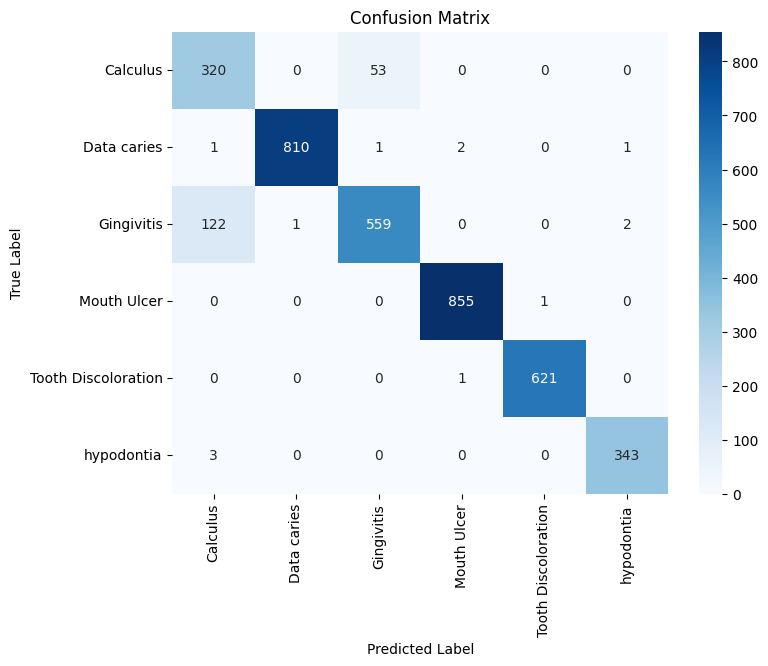

In [ ]:
# ===============================
# SECTION 14: Confusion Matrix
# ===============================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

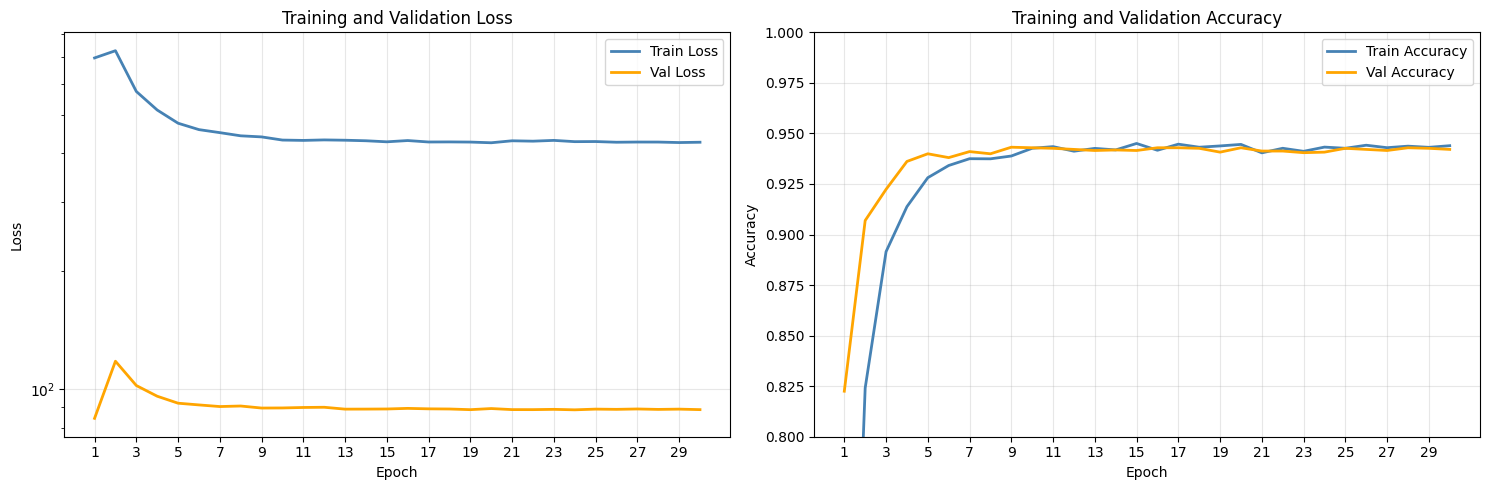


📊 TRAINING SUMMARY
   Best Val Accuracy   : 0.9432 (Epoch 9)
   Final Train Accuracy: 0.9439
   Final Val Accuracy  : 0.9421
   Final Train Loss    : 425.5865
   Final Val Loss      : 88.8714


In [ ]:
# ===============================
# SECTION 15: Plot Training History
# ===============================

def plot_training_history(train_losses, val_losses, val_accuracies, train_accuracies):

    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(15, 5))

    # -------- LOSS GRAPH --------
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Train Loss', linewidth=2, color='steelblue')
    plt.plot(epochs, val_losses, label='Val Loss', linewidth=2, color='orange')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.yscale('log')
    plt.xticks(range(1, len(train_losses) + 1, 2))
    plt.legend()
    plt.grid(True, alpha=0.3)

    # -------- ACCURACY GRAPH --------
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, label='Train Accuracy', linewidth=2, color='steelblue')
    plt.plot(epochs, val_accuracies, label='Val Accuracy', linewidth=2, color='orange')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim(0.8, 1.0)
    plt.xticks(range(1, len(val_accuracies) + 1, 2))
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('/content/training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ✅ Print summary
    print(f"\n📊 TRAINING SUMMARY")
    print(f"   Best Val Accuracy   : {max(val_accuracies):.4f} (Epoch {val_accuracies.index(max(val_accuracies)) + 1})")
    print(f"   Final Train Accuracy: {train_accuracies[-1]:.4f}")
    print(f"   Final Val Accuracy  : {val_accuracies[-1]:.4f}")
    print(f"   Final Train Loss    : {train_losses[-1]:.4f}")
    print(f"   Final Val Loss      : {val_losses[-1]:.4f}")

# ✅ Call with all 4 arguments
plot_training_history(train_losses, val_losses, val_accuracies, train_accuracies)

/tmp/ipykernel_2790/937046837.py:188: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2790/937046837.py:188: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2790/937046837.py:189: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/gradcam_visualization.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_2790/937046837.py:189: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/gradcam_visualization.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) m

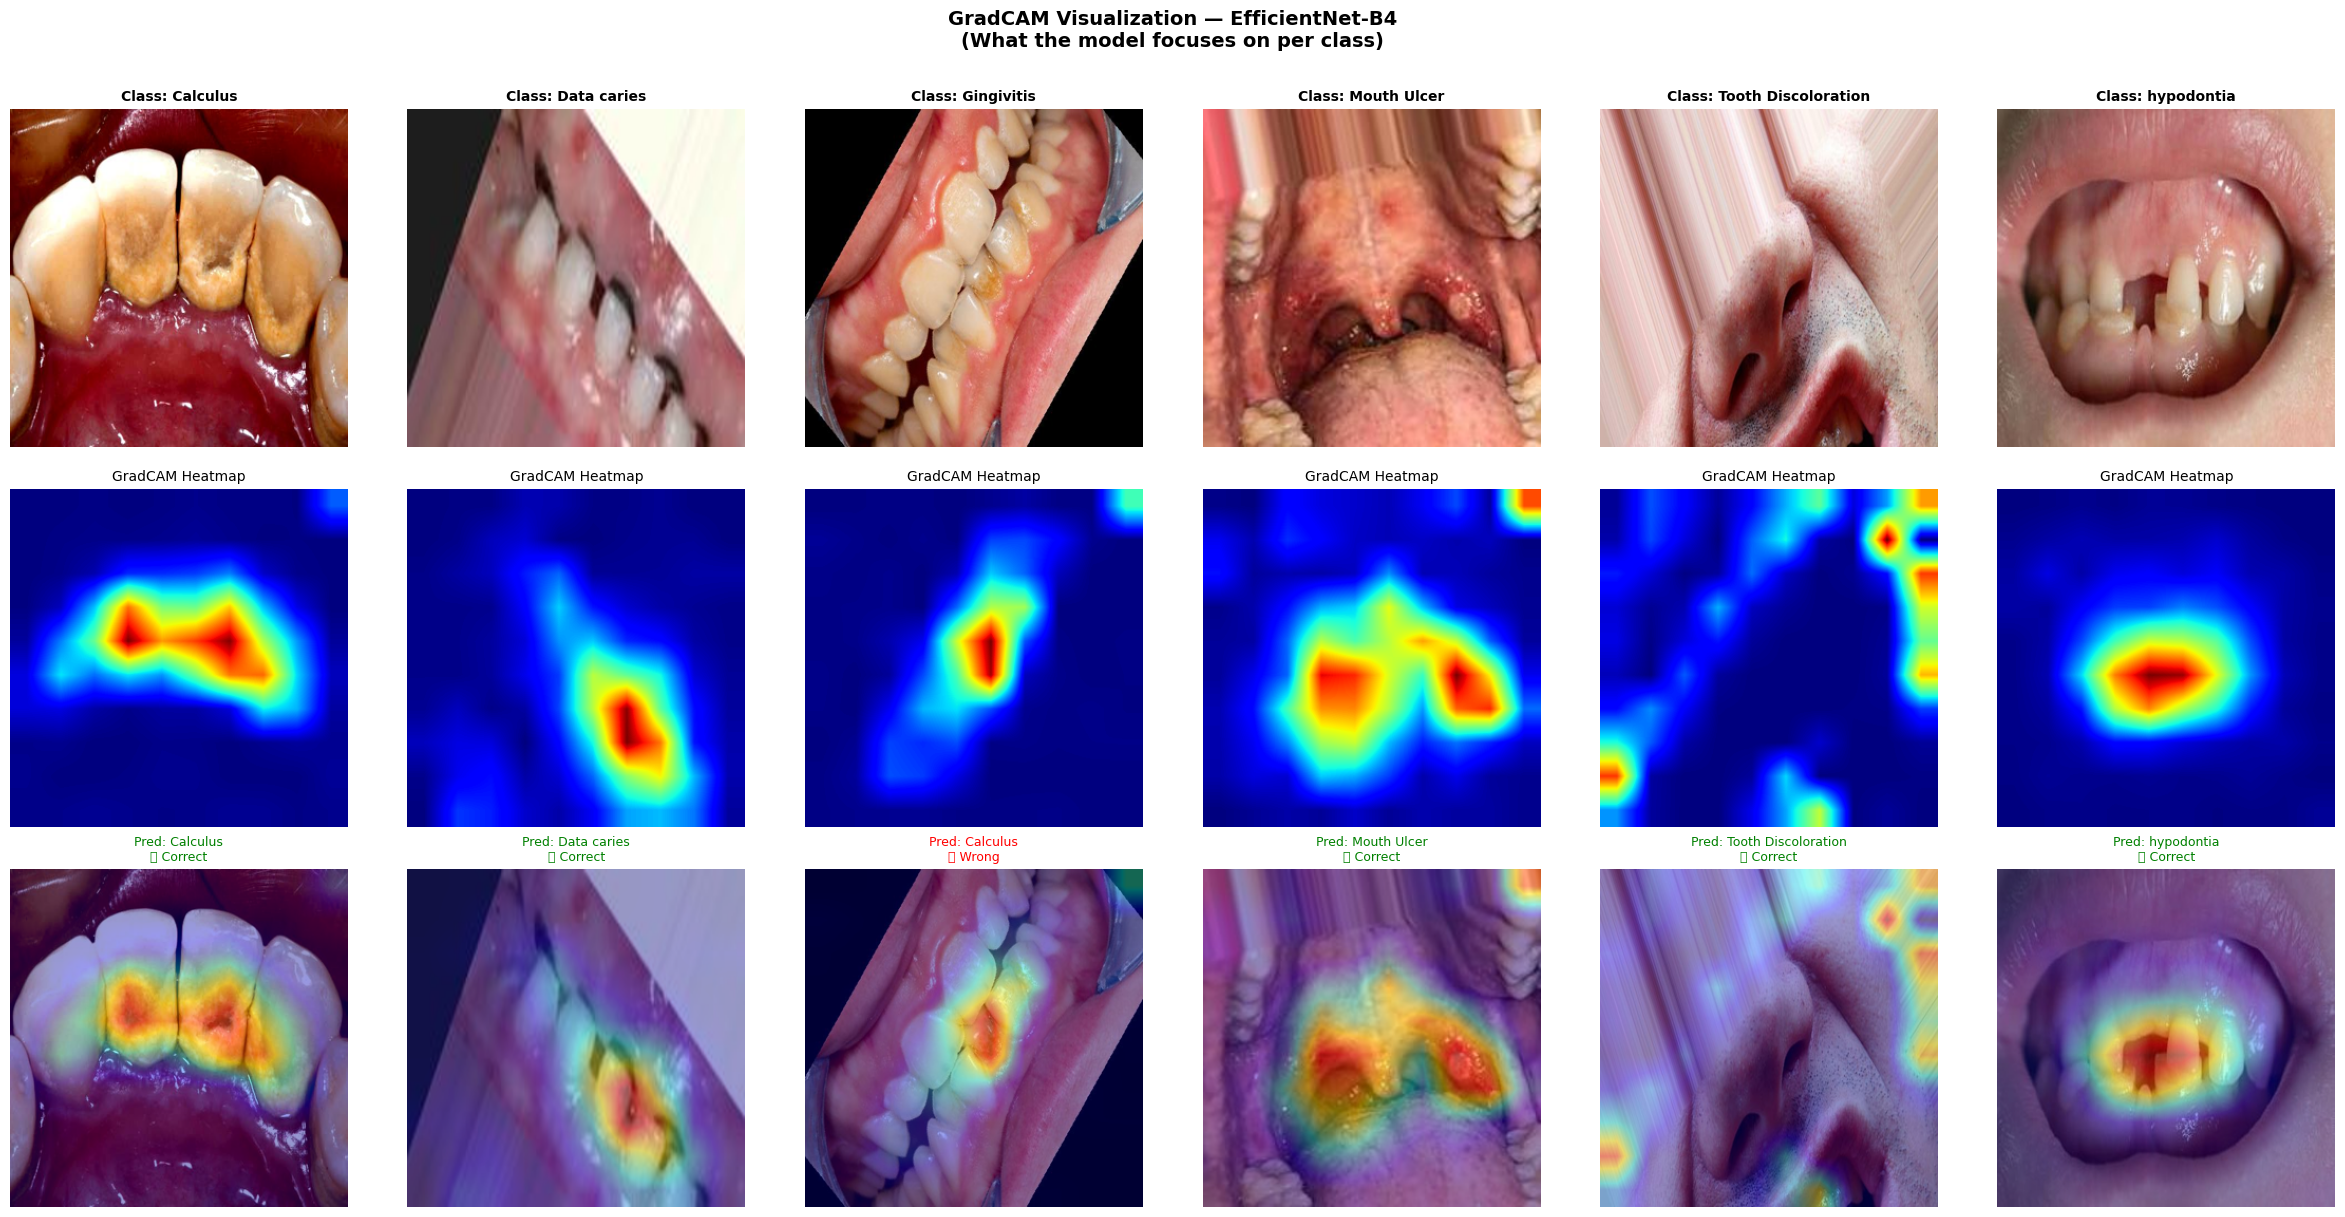

✅ GradCAM saved to /content/gradcam_visualization.png


In [ ]:
# ===============================
# SECTION 16: GradCAM Visualization
# ===============================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import random

# ===============================
# GRADCAM CLASS.       jai shri ganesh
# ===============================

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # ✅ Register hooks to capture gradients and activations
        self.target_layer.register_forward_hook(self._save_activation)
        self.target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):

        self.model.eval()

        # Forward pass
        output = self.model(input_tensor)

        # Use predicted class if none given
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        # Zero gradients
        self.model.zero_grad()

        # Backward pass for target class
        one_hot = torch.zeros_like(output)
        one_hot[0][class_idx] = 1
        output.backward(gradient=one_hot)

        # Compute GradCAM heatmap
        gradients = self.gradients[0]           # [C, H, W]
        activations = self.activations[0]       # [C, H, W]

        # Global average pooling on gradients
        weights = gradients.mean(dim=(1, 2))    # [C]

        # Weighted sum of activations
        cam = torch.zeros(activations.shape[1:], device=activations.device)
        for i, w in enumerate(weights):
            cam += w * activations[i]

        # Apply ReLU (keep only positive values)
        cam = F.relu(cam)

        # Normalize to 0-1
        cam = cam - cam.min()
        if cam.max() != 0:
            cam = cam / cam.max()

        return cam.cpu().numpy(), class_idx


# ===============================
# HELPER: Overlay heatmap on image
# ===============================

def apply_heatmap(image_np, cam, alpha=0.4):

    # Resize CAM to match image size
    cam_resized = cv2.resize(cam, (image_np.shape[1], image_np.shape[0]))

    # Convert to heatmap (colormap)
    heatmap = cv2.applyColorMap(
        np.uint8(255 * cam_resized), cv2.COLORMAP_JET
    )
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # Overlay heatmap on original image
    overlay = np.uint8(alpha * heatmap + (1 - alpha) * image_np)

    return overlay, cam_resized


# ===============================
# SETUP GRADCAM
# ===============================

# Load best model
model.load_state_dict(torch.load("/content/best_model.pth"))
model.eval()
model = model.to(device)

# ✅ Target last conv layer of EfficientNet-B4
target_layer = model.features[-1]

# Initialize GradCAM
gradcam = GradCAM(model, target_layer)


# ===============================
# VISUALIZE: 1 sample per class
# ===============================

# Group test samples by class
class_to_indices = {i: [] for i in range(num_classes)}

for idx in test_idx:
    label = full_dataset.targets[idx]
    class_to_indices[label].append(idx)

# Number of columns = number of classes
num_cols = num_classes
fig, axes = plt.subplots(3, num_cols, figsize=(num_cols * 4, 12))

for class_id in range(num_classes):

    # Pick a random sample from this class
    sample_idx = random.choice(class_to_indices[class_id])

    # Load original image (no transform)
    original_img, true_label = full_dataset[sample_idx]

    # Convert PIL to numpy for display
    img_np = np.array(original_img.resize((IMG_SIZE, IMG_SIZE)))

    # Prepare tensor for model
    input_tensor = eval_transform(
        original_img.resize((IMG_SIZE, IMG_SIZE))
    ).unsqueeze(0).to(device)

    # Generate GradCAM
    cam, pred_class = gradcam.generate(input_tensor)

    # Apply heatmap
    overlay, cam_resized = apply_heatmap(img_np, cam)

    # -------- ROW 1: Original Image --------
    axes[0][class_id].imshow(img_np)
    axes[0][class_id].set_title(
        f"Class: {class_names[class_id]}",
        fontsize=10, fontweight='bold'
    )
    axes[0][class_id].axis('off')

    # -------- ROW 2: GradCAM Heatmap --------
    axes[1][class_id].imshow(cam_resized, cmap='jet')
    axes[1][class_id].set_title("GradCAM Heatmap", fontsize=10)
    axes[1][class_id].axis('off')

    # -------- ROW 3: Overlay --------
    axes[2][class_id].imshow(overlay)

    # Show if prediction is correct
    status = "✅ Correct" if pred_class == true_label else "❌ Wrong"
    axes[2][class_id].set_title(
        f"Pred: {class_names[pred_class]}\n{status}",
        fontsize=9,
        color='green' if pred_class == true_label else 'red'
    )
    axes[2][class_id].axis('off')

# Row labels
axes[0][0].set_ylabel("Original", fontsize=12, fontweight='bold')
axes[1][0].set_ylabel("GradCAM", fontsize=12, fontweight='bold')
axes[2][0].set_ylabel("Overlay", fontsize=12, fontweight='bold')

plt.suptitle(
    "GradCAM Visualization — EfficientNet-B4\n(What the model focuses on per class)",
    fontsize=14,
    fontweight='bold',
    y=1.01
)

plt.tight_layout()
plt.savefig('/content/gradcam_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ GradCAM saved to /content/gradcam_visualization.png")

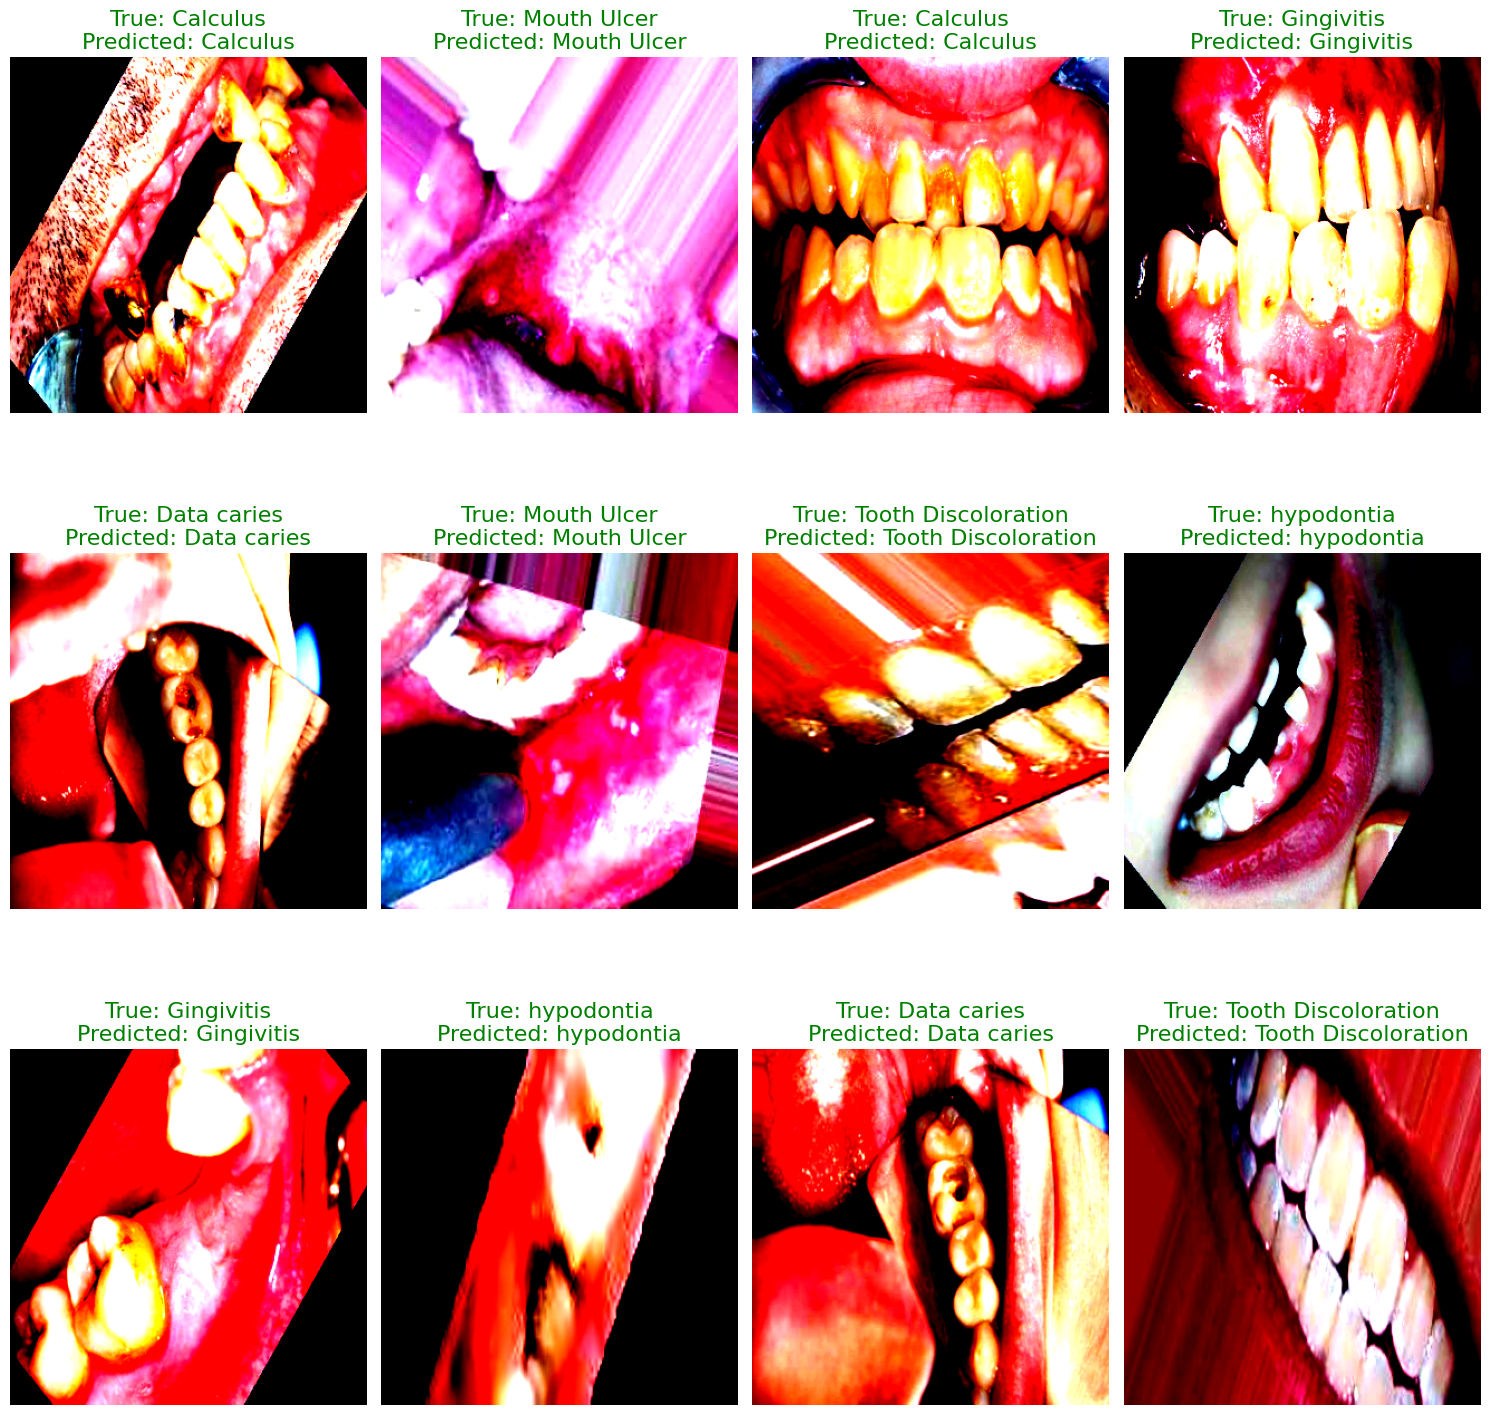

In [ ]:
# ============================================
# STEP 11: VISUALIZE MODEL PREDICTIONS
# ============================================

# Set seed for reproducibility
random.seed(42)

# Function to display random images with true & predicted labels
def display_random__predicted_images(model, test_loader, class_names, num_images_per_class=5):

    # Set model to evaluation mode
    model.eval()

    # Create large figure
    plt.figure(figsize=(15, 30))

    images_so_far = 0

    # Track how many images per class are shown
    class_counts = {classname: 0 for classname in class_names}

    # Track already shown images
    shown_images = []

    # Disable gradients
    with torch.no_grad():

        for i, (inputs, labels) in enumerate(test_loader):

            inputs = inputs.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(inputs)

            # Get predictions
            _, preds = torch.max(outputs, 1)

            # Iterate over batch
            for j in range(inputs.size(0)):

                # Get class names
                true_class_name = class_names[labels[j].item()]
                predicted_class_name = class_names[preds[j].item()]

                # Display limited images per class
                if class_counts[true_class_name] < num_images_per_class and (true_class_name, j) not in shown_images:

                    images_so_far += 1

                    ax = plt.subplot(
                        len(class_names),
                        num_images_per_class * 2,
                        images_so_far
                    )

                    ax.axis('off')

                    # Color: green (correct), red (wrong)
                    if true_class_name == predicted_class_name:
                        title_color = 'green'
                    else:
                        title_color = 'red'

                    # Set title
                    ax.set_title(
                        f'True: {true_class_name}\nPredicted: {predicted_class_name}',
                        fontsize=16,
                        color=title_color
                    )

                    # Show image
                    plt.imshow(inputs.cpu().data[j].permute(1, 2, 0))

                    # Update count
                    class_counts[true_class_name] += 1
                    shown_images.append((true_class_name, j))

                # Stop when enough images shown
                if images_so_far >= len(class_names) * num_images_per_class:
                    return


# Call function
display_random__predicted_images(
    model,
    test_loader,
    class_names,
    num_images_per_class=2
)

plt.tight_layout()
plt.show()